In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, MaxNLocator


# Exploración de datos

In [2]:
df = pd.read_csv('data/raw.csv')

In [4]:
print("\nMissing Values per Column:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])



Missing Values per Column:
Color                        389
Transmisión                   15
Motor                         38
Con cámara de retroceso    13563
dtype: int64


## Marca

Análisis de Marcas:

Cantidad total de marcas únicas: 47

Top 10 marcas más frecuentes:
Marca
Ford          2161
Jeep          2050
Volkswagen    2037
Chevrolet     1750
Renault       1491
Toyota        1260
Peugeot       1250
Nissan        1059
Citroën        721
BMW            672
Name: count, dtype: int64


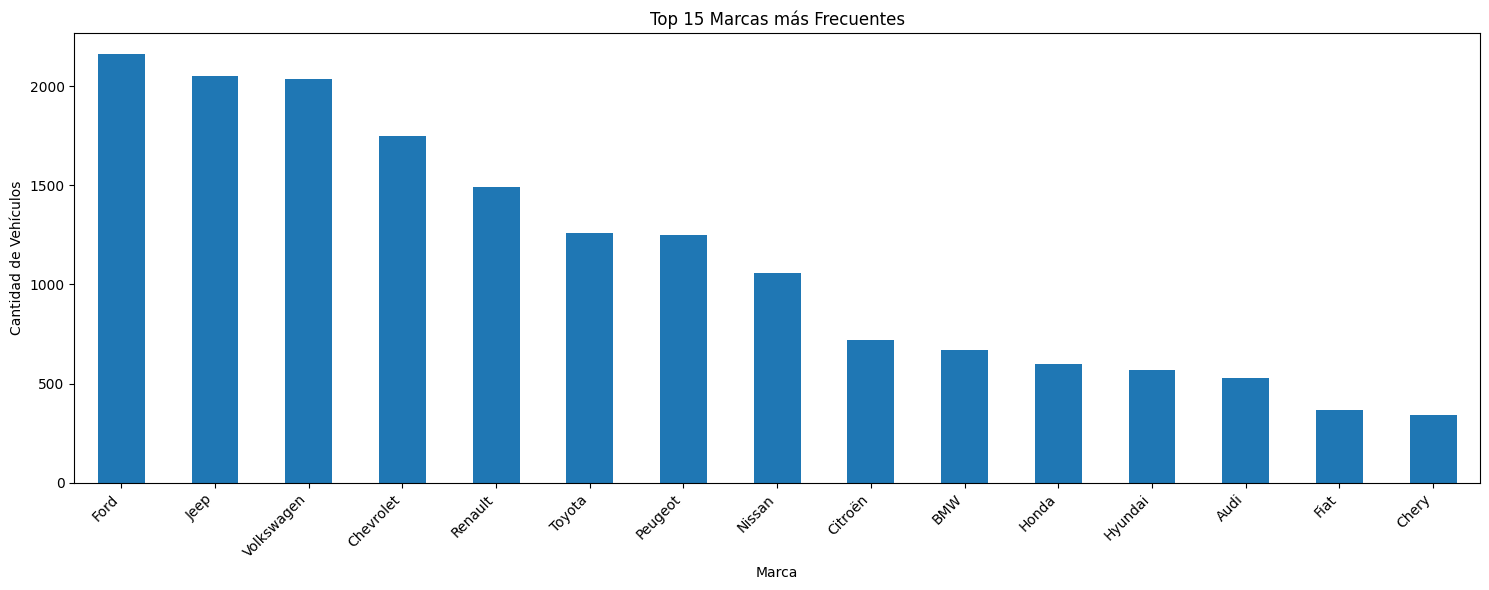

In [5]:
# Count of vehicles by brand
brand_counts = df['Marca'].value_counts()

# Display statistics
print("Análisis de Marcas:")
print(f"\nCantidad total de marcas únicas: {len(brand_counts)}")
print("\nTop 10 marcas más frecuentes:")
print(brand_counts.head(10))

# Plotting
plt.figure(figsize=(15, 6))
brand_counts.head(15).plot(kind='bar')
plt.title('Top 15 Marcas más Frecuentes')
plt.xlabel('Marca')
plt.ylabel('Cantidad de Vehículos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

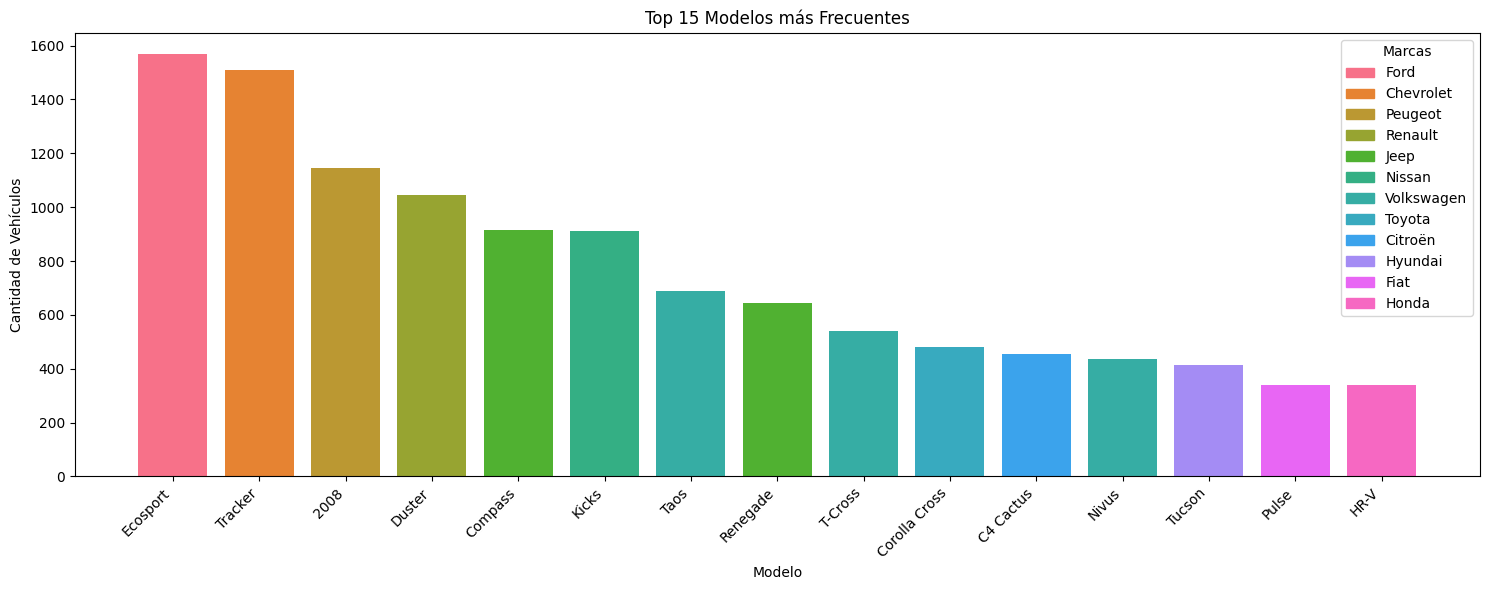


Top 15 modelos más frecuentes (con su marca):
       Modelo      Marca  count
     Ecosport       Ford   1569
      Tracker  Chevrolet   1511
         2008    Peugeot   1144
       Duster    Renault   1047
      Compass       Jeep    916
        Kicks     Nissan    913
         Taos Volkswagen    687
     Renegade       Jeep    643
      T-Cross Volkswagen    539
Corolla Cross     Toyota    482
    C4 Cactus    Citroën    453
        Nivus Volkswagen    436
       Tucson    Hyundai    415
        Pulse       Fiat    341
         HR-V      Honda    339


In [6]:
# Count of vehicles by model and brand
model_brand_counts = df.groupby(['Modelo', 'Marca']).size().reset_index(name='count')
model_counts = model_brand_counts.sort_values('count', ascending=False)

# Get top 15 models
top_15_models = model_counts.head(15)

# Create a color map for brands
unique_brands = top_15_models['Marca'].unique()
color_palette = sns.color_palette("husl", len(unique_brands))
brand_colors = dict(zip(unique_brands, color_palette))

# Plotting
plt.figure(figsize=(15, 6))

# Create bars with colors based on brand
bars = plt.bar(range(len(top_15_models)), top_15_models['count'], 
               color=[brand_colors[marca] for marca in top_15_models['Marca']])

# Create legend
legend_elements = [plt.Rectangle((0,0),1,1, color=color, label=brand) 
                  for brand, color in brand_colors.items()]
plt.legend(handles=legend_elements, title="Marcas", loc='upper right')

# Customize the plot
plt.title('Top 15 Modelos más Frecuentes')
plt.xlabel('Modelo')
plt.ylabel('Cantidad de Vehículos')

# Set x-axis labels (only models, as brands are shown by color)
plt.xticks(range(len(top_15_models)), top_15_models['Modelo'], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Display statistics
print("\nTop 15 modelos más frecuentes (con su marca):")
print(top_15_models[['Modelo', 'Marca', 'count']].to_string(index=False))

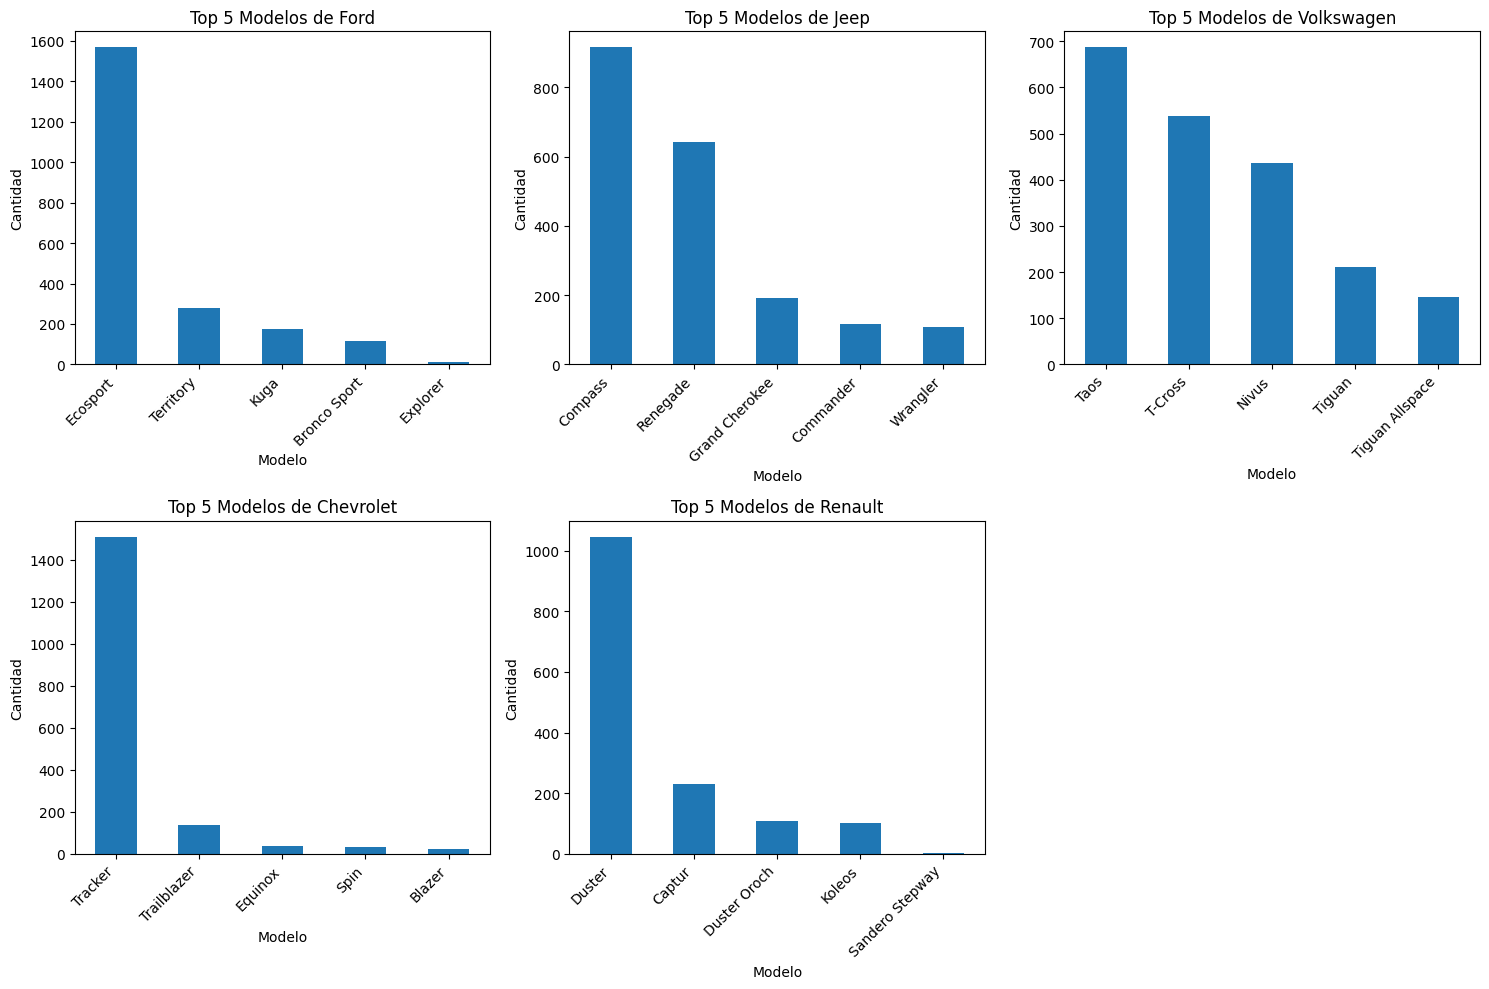

In [7]:
top_5_marcas = brand_counts.head(5).index

plt.figure(figsize=(15, 10))
for i, marca in enumerate(top_5_marcas, 1):
    plt.subplot(2, 3, i)
    df[df['Marca'] == marca]['Modelo'].value_counts().head(5).plot(kind='bar')
    plt.title(f'Top 5 Modelos de {marca}')
    plt.xlabel('Modelo')
    plt.ylabel('Cantidad')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

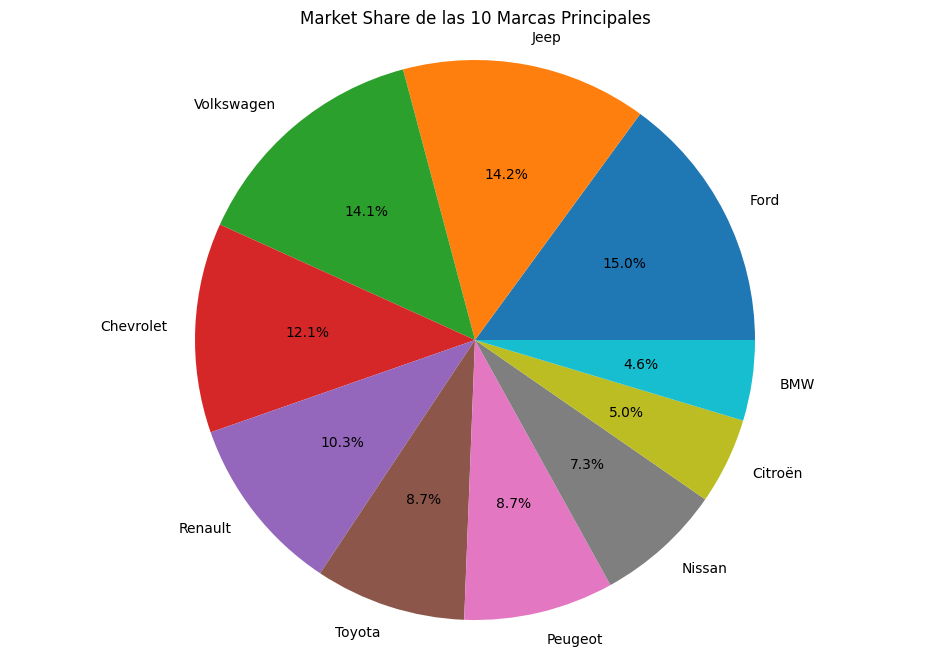

In [8]:
# Calculate market share by brand
market_share = (df['Marca'].value_counts() / len(df) * 100).round(2)

# Create a pie chart for top 10 brands
plt.figure(figsize=(12, 8))
plt.pie(market_share.head(10), labels=market_share.head(10).index, autopct='%1.1f%%')
plt.title('Market Share de las 10 Marcas Principales')
plt.axis('equal')
plt.show()

## Kilometraje

In [68]:
# Filtro

kilometers = (
    df['Kilómetros']
    .astype(str)
    .str.lower()
    .str.replace('km', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('', np.nan)
    .astype(float)
)

df['Kilómetros'] = kilometers

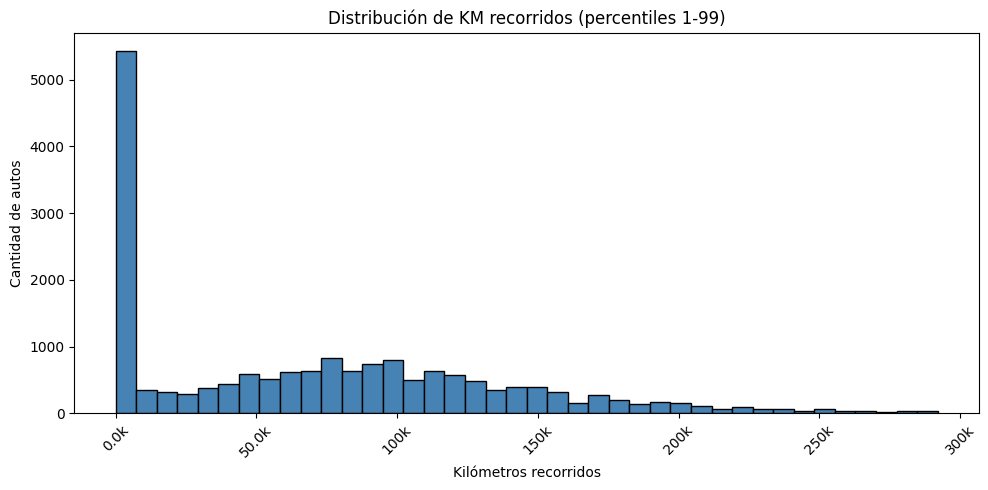

In [69]:
p1  = np.percentile(kilometers, 1)
p99 = np.percentile(kilometers, 99)
filtered_km = kilometers[(kilometers >= p1) & (kilometers <= p99)]

# --- histograma ---
plt.figure(figsize=(10, 5))
plt.hist(filtered_km, bins=40, color="steelblue", edgecolor="black")
plt.xlabel("Kilómetros recorridos")
plt.ylabel("Cantidad de autos")
plt.title("Distribución de KM recorridos (percentiles 1-99)")

# --- ticks cada 50 000 km (cambiá step_km si querés 10 k, 25 k, etc.) ---
step_km = 50_000           # 50 k
xmin, xmax = 0, filtered_km.max()
ticks = np.arange(xmin, xmax + step_km, step_km)
plt.xticks(ticks)

# --- formateo: un decimal cuando hace falta ---
def km_formatter(x, pos):
    val_k = x / 1_000      # pasamos a miles
    if val_k < 100:        # < 100k  → un decimal
        return f"{val_k:,.1f}k".replace(",", ".")
    else:                  # ≥ 100k  → entero
        return f"{val_k:,.0f}k".replace(",", ".")

plt.gca().xaxis.set_major_formatter(FuncFormatter(km_formatter))
plt.gca().tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


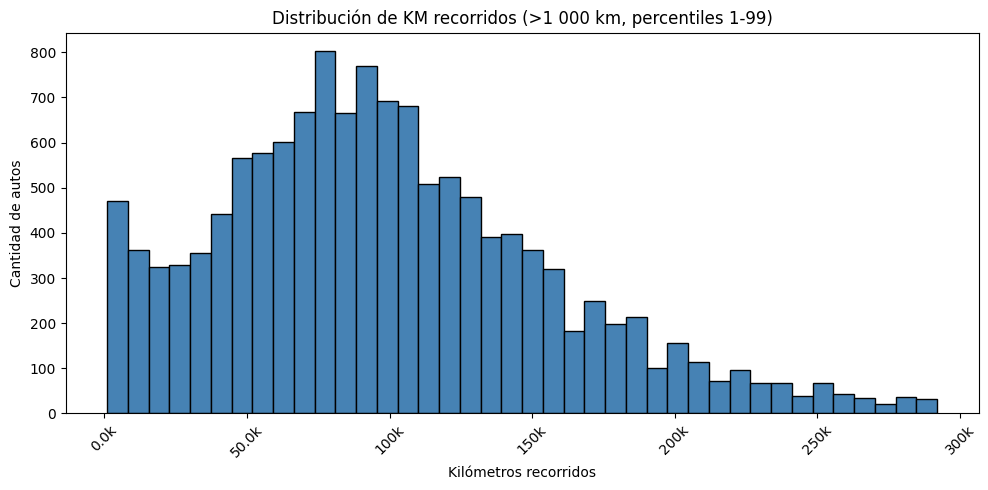

In [70]:
used_km = filtered_km[filtered_km > 1_000]

plt.figure(figsize=(10, 5))
plt.hist(used_km, bins=40, color="steelblue", edgecolor="black")
plt.xlabel("Kilómetros recorridos")
plt.ylabel("Cantidad de autos")
plt.title("Distribución de KM recorridos (>1 000 km, percentiles 1-99)")

# mismo eje X
step_km = 50_000
ticks = np.arange(0, used_km.max() + step_km, step_km)
plt.xticks(ticks)

def km_formatter(x, pos):
    val_k = x / 1_000
    return f"{val_k:,.1f}k".replace(",", ".") if val_k < 100 else f"{val_k:,.0f}k".replace(",", ".")

plt.gca().xaxis.set_major_formatter(FuncFormatter(km_formatter))
plt.gca().tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Precio

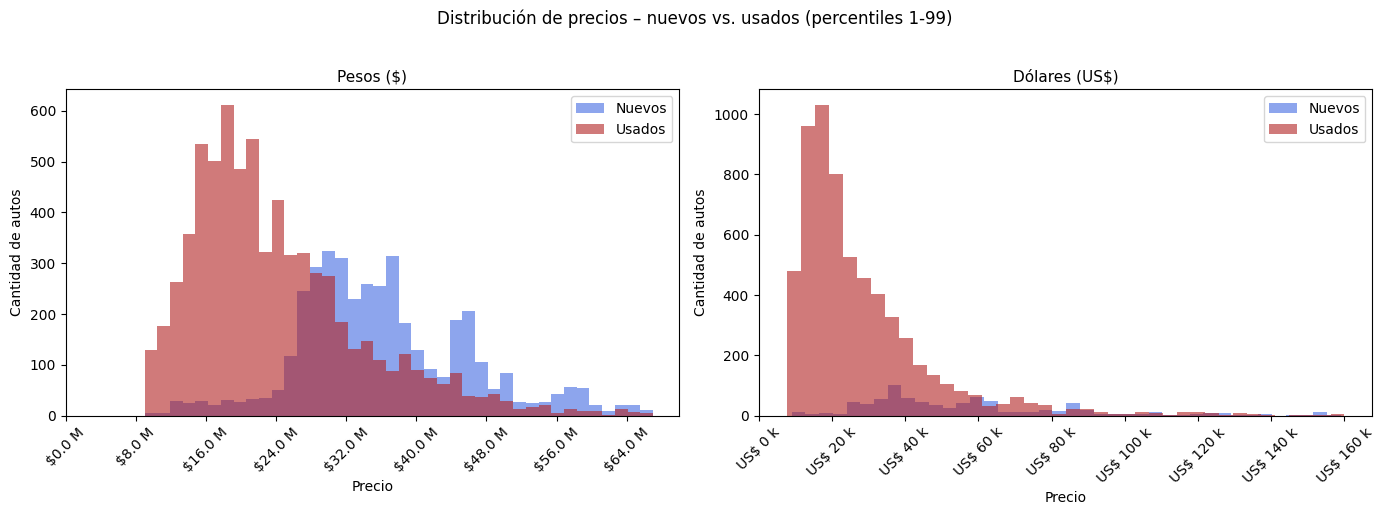

In [ ]:
mask_pesos = df['Moneda'] == '$'
mask_usd   = df['Moneda'].str.contains('US')
mask_new   = df['Kilómetros'] <= 1_000
mask_used  = df['Kilómetros'] > 1_000



def plot_overlay(ax, data_new, data_used, title, step, formatter):
    all_prices = pd.concat([data_new, data_used])
    p1, p99 = np.percentile(all_prices, [1, 99])

    new_filt  = data_new[(data_new  >= p1) & (data_new  <= p99)]
    used_filt = data_used[(data_used >= p1) & (data_used <= p99)]

    ax.hist(new_filt,  bins=40, color="royalblue", alpha=0.6, label="Nuevos")
    ax.hist(used_filt, bins=40, color="firebrick", alpha=0.6, label="Usados")

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Precio")
    ax.set_ylabel("Cantidad de autos")
    ax.legend()

    ticks = np.arange(0, p99 + step, step)
    ax.set_xticks(ticks)
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
    ax.tick_params(axis="x", rotation=45)



fmt_pesos = FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f} M")
fmt_usd   = FuncFormatter(lambda x, pos: f"US$ {x/1_000:.0f} k")


fig, (ax_pesos, ax_usd) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de precios – nuevos vs. usados (percentiles 1-99)", y=1.02)

plot_overlay(
    ax_pesos,
    df.loc[mask_pesos & mask_new,  'Precio'],
    df.loc[mask_pesos & mask_used, 'Precio'],
    "Pesos ($)",
    step=5_000_000,
    formatter=fmt_pesos
)

plot_overlay(
    ax_usd,
    df.loc[mask_usd & mask_new,  'Precio'],
    df.loc[mask_usd & mask_used, 'Precio'],
    "Dólares (US$)",
    step=5_000,
    formatter=fmt_usd
)

plt.tight_layout()
plt.show()

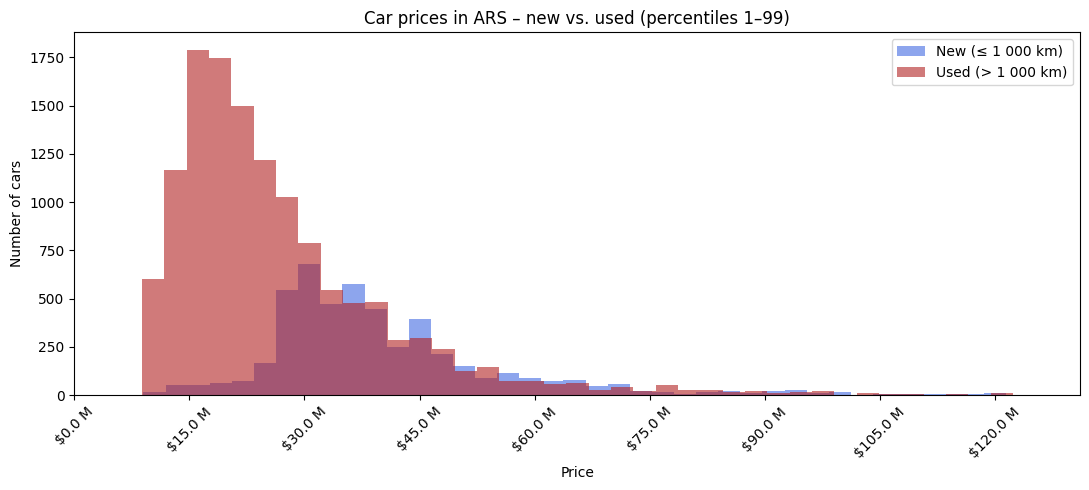

In [ ]:
exchange_rate = 1100

price_ars = df["Precio"].copy()
price_ars[df["Moneda"].str.contains("US")] *= exchange_rate

new_mask  = df["Kilómetros"] <= 1_000
used_mask = df["Kilómetros"] >  1_000

p_low, p_high = np.percentile(price_ars, [1, 99])

new_prices  = price_ars[new_mask]
used_prices = price_ars[used_mask]

new_filtered  = new_prices[(new_prices  >= p_low) & (new_prices  <= p_high)]
used_filtered = used_prices[(used_prices >= p_low) & (used_prices <= p_high)]

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(new_filtered,  bins=40, color="royalblue", alpha=0.6, label="New (≤ 1 000 km)")
ax.hist(used_filtered, bins=40, color="firebrick", alpha=0.6, label="Used (> 1 000 km)")

ax.set_title("Car prices in ARS – new vs. used (percentiles 1–99)")
ax.set_xlabel("Price")
ax.set_ylabel("Number of cars")
ax.legend()

# X-axis ticks and formatting
tick_step = 5_000_000                                  # 5 million ARS
ticks = np.arange(0, p_high + tick_step, tick_step)
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f} M"))
ax.xaxis.set_major_locator(MaxNLocator(nbins=10))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

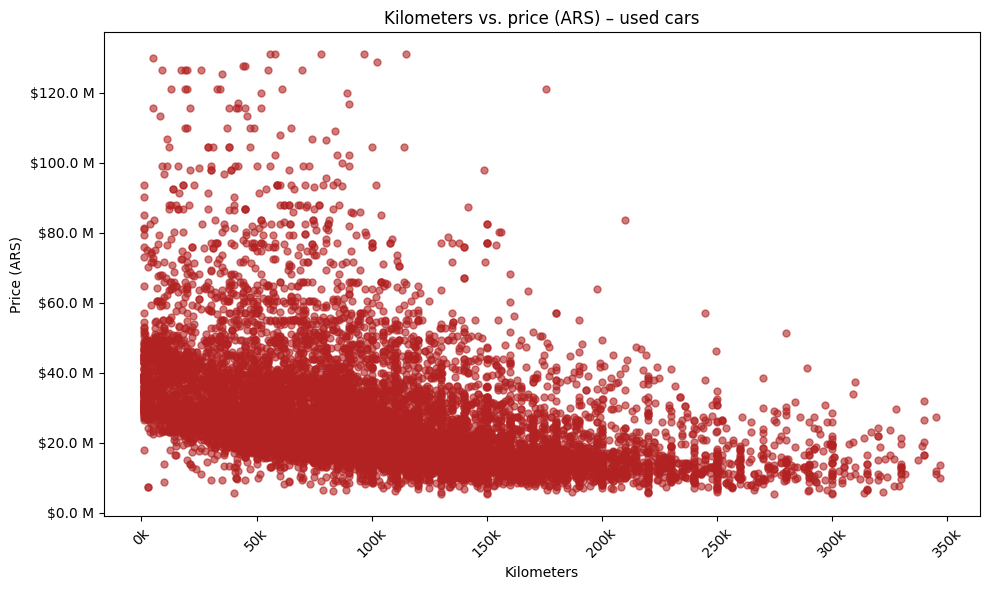

In [81]:
km_low, km_high       = np.percentile(kilometers[used_mask], [.1, 99.5])
price_low, price_high = np.percentile(price_ars[used_mask], [.1, 99.5])
in_range = (kilometers.between(km_low, km_high) &
            price_ars.between(price_low, price_high) &
            used_mask)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(kilometers[in_range],
           price_ars[in_range],
           s=25, color="firebrick", alpha=0.6)

ax.set_title("Kilometers vs. price (ARS) – used cars")
ax.set_xlabel("Kilometers")
ax.set_ylabel("Price (ARS)")

# axis formatters
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000:.0f}k"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"${y/1_000_000:.1f} M"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


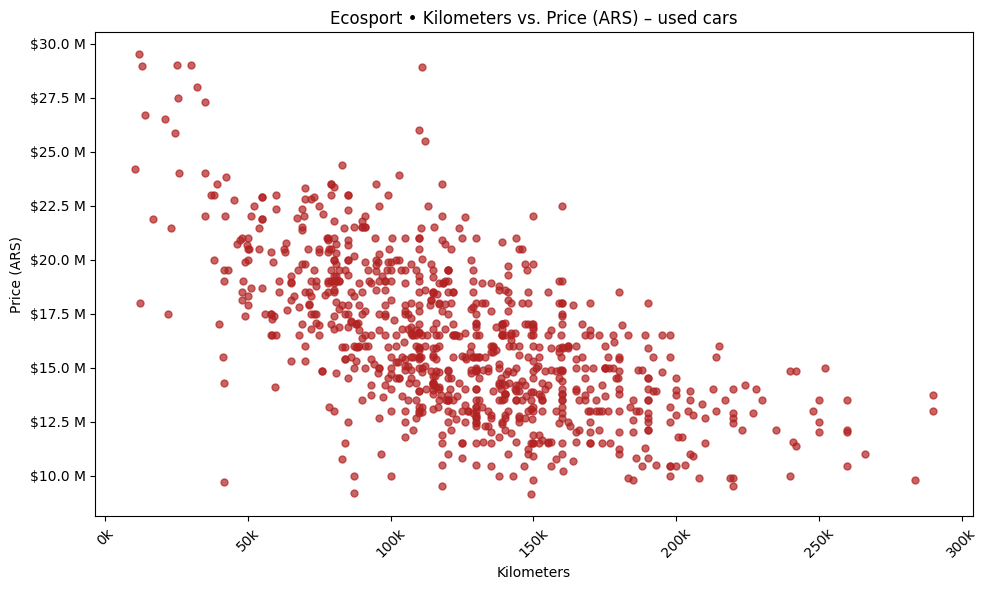

In [ ]:
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------------
# 1) seleccionar SOLO dusters usados
# ------------------------------------------------------------------
model_mask = df["Modelo"].str.lower() == "duster"
selection  = used_mask & model_mask            # (>1 000 km  y  modelo Ecosport)

km_sel    = kilometers[selection]
price_sel = price_ars[selection]

# ------------------------------------------------------------------
# 2) (opcional) recorte 1–99 % para limpiar outliers extremos
# ------------------------------------------------------------------
km_low, km_high       = np.percentile(km_sel,   [1, 99])
price_low, price_high = np.percentile(price_sel, [1, 99])

in_range = (
    km_sel.between(km_low, km_high) &
    price_sel.between(price_low, price_high)
)

# ------------------------------------------------------------------
# 3) scatter plot
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    km_sel[in_range],
    price_sel[in_range],
    s=25,
    color="firebrick",
    alpha=0.7
)

ax.set_title("Ecosport • Kilometers vs. Price (ARS) – used cars")
ax.set_xlabel("Kilometers")
ax.set_ylabel("Price (ARS)")

# formato de ejes
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1_000:.0f}k"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"${y/1_000_000:.1f} M"))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()
